# Aplicaciones de modelos clasicos.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
Sa_Crustal = ['T_0.01_RotD50', 'T_0.02_RotD50', 'T_0.03_RotD50', 'T_0.04_RotD50',
       'T_0.05_RotD50','T_0.075_RotD50','T_0.1_RotD50','T_0.15_RotD50','T_0.2_RotD50','T_0.25_RotD50','T_0.3_RotD50',
        'T_0.4_RotD50','T_0.5_RotD50','T_0.75_RotD50','T_1.0_RotD50','T_1.5_RotD50','T_2.0_RotD50','T_3.0_RotD50',
        'T_4.0_RotD50','T_5.0_RotD50','T_6.0_RotD50','T_10.0_RotD50']

## Preparación de los datos.

In [3]:
df = pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/FinalProjectDL/Final_Project/Updated_NGA_West2_Flatfile_RotD50EDITADO.xlsx')
df = df[df['Vs30 (m/s) selected for analysis'] > 0]
df = df[df['Magnitude Type'] == 'Mw']

In [4]:
df.drop(columns=['Record Sequence Number','Earthquake Name',
                'Magnitude Type','EpiD (km)','Joyner-Boore Dist. (km)',
                'RmsD (km)','Rx','Vs30 (m/s) selected for analysis',
                #'Tmax',
                 'Lowest Usable Freq - Ave. Component (Hz)',
                'PGA (g)','PGV (cm/sec)','PGD (cm)'], inplace=True)

In [5]:
inputs = df.columns[0:9]

In [6]:
var = inputs.tolist() + Sa_Crustal

In [7]:
df_Col = pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/FinalProjectDL/Final_Project/CopiaDataBaseSGC.xlsx')
df_Col[Sa_Crustal]=df_Col[Sa_Crustal]/980

In [8]:
columnas_a_eliminar = [
    "Record Sequence Number", "Station ID", "Station Code", "Magnitude type", "EQID", "Valor_T1.5",
    #"Tmax", 
    #"Epicenter Latitude (deg; positive N)", "Epicenter Longitude (deg; positive E)",
    #"Station Latitude (deg positive N)", "Station Longitude (deg positive E)",
    "Topografía", "Geología",
    "Nodal Plane 1 Rake Angle (deg)", "Nodal Plane 2 Rake Angle (deg)",
    "Nodal Plane 2 Dip (deg)", "Nodal Plane 2 Strike (deg)",
    "Rx_OpenQuake", "Ry0_OpenQuake", "Rjb_OpenQuake",
    "Repi_OpenQuake",
    # "Rhypo_OpenQuake",
    "Station Elevation (m)",
    #"Soil_Class",
    "Nodal Plane 1 Strike (deg)", "Nodal Plane 1 Dip (deg)",
    "Fault Plane (1; 2; X)", "Style-of-Faulting (S; R; N; U)",
    "Tn",
    'Record Sequence Number','EQID','Magnitude type',
    'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'
]

In [9]:
df_Col = df_Col[df_Col['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']=='Crustal']

In [10]:
df_Col.drop(columns=columnas_a_eliminar, inplace=True)

In [11]:
df_Col = df_Col[df_Col['T_0.01_RotD50']>=1e-7]

In [12]:
df = df.rename(columns={"Hypocenter Latitude (deg)": "Seismic Latitude"})
df = df.rename(columns={"Hypocenter Longitude (deg)": "Seismic Longitude"})
df_Col = df_Col.rename(columns={"Epicenter Latitude (deg; positive N)": "Seismic Latitude"})
df_Col = df_Col.rename(columns={"Epicenter Longitude (deg; positive E)": "Seismic Longitude"})
df_Col = df_Col.rename(columns={"Station Latitude (deg positive N)": "Station Latitude"})
df_Col = df_Col.rename(columns={"Station Longitude (deg positive E)": "Station Longitude"})

In [13]:
inputs = df.columns[0:9]
inputs

Index(['Seismic Latitude', 'Seismic Longitude', 'Station Latitude',
       'Station Longitude', 'Hypocenter Depth (km)', 'Magnitude',
       'Rhypo_OpenQuake', 'Rrup_OpenQuake', 'Soil_Class'],
      dtype='object')

In [14]:
var = inputs.tolist() + Sa_Crustal
df_Col=df_Col[var]

In [15]:
df_Col['origen'] = 'Colombia'
df['origen'] = 'NGAW2'

In [16]:
df_total = pd.concat([df, df_Col], ignore_index=True)

In [17]:
df_total

,Seismic Latitude,Seismic Longitude,Station Latitude,Station Longitude,Hypocenter Depth (km),Magnitude,Rhypo_OpenQuake,Rrup_OpenQuake,Soil_Class,Tmax,...,T_0.75_RotD50,T_1.0_RotD50,T_1.5_RotD50,T_2.0_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_10.0_RotD50,origen
0,46.6100,-111.9600,46.5800,-112.0300,6.0,6.0000,8.710000,2.860000,3,6.153846,...,0.092829,0.101136,0.059109,0.035895,1.525704e-02,7.987177e-03,4.643577e-03,3.036607e-03,NaN,NGAW2
1,40.4000,-125.1000,40.5760,-124.2630,10.0,5.8000,74.170000,71.570000,4,2.666667,...,0.056946,0.035785,0.016157,0.009347,2.959554e-03,NaN,NaN,NaN,NaN,NGAW2
2,40.3000,-124.8000,40.5760,-124.2630,10.0,5.5000,55.780000,53.580000,4,1.600000,...,0.091499,0.093659,0.026785,0.013654,NaN,NaN,NaN,NaN,NaN,NGAW2
3,32.7601,-115.4162,32.7940,-115.5490,8.8,6.9500,15.690000,6.090000,4,4.000000,...,0.435350,0.351286,0.197357,0.215745,1.063604e-01,4.696507e-02,NaN,NaN,NaN,NGAW2
4,40.2830,-124.8000,40.5760,-124.2630,10.0,5.8000,56.850000,53.770000,4,2.000000,...,0.124190,0.085661,0.040947,0.019499,NaN,NaN,NaN,NaN,NaN,NGAW2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17507,3.4400,-74.1900,1.1890,-77.3220,10.0,4.1000,428.905798,428.091130,5,NaN,...,0.000002,0.000001,0.000001,0.000001,1.087456e-06,6.427327e-07,3.359714e-07,2.371388e-07,6.632653e-08,Colombia
17508,3.4300,-74.2000,1.1890,-77.3220,18.0,4.0000,427.631871,426.956629,5,NaN,...,0.000002,0.000001,0.000001,0.000001,9.019724e-07,4.762469e-07,2.486122e-07,1.713980e-07,6.234694e-08,Colombia
17509,3.4100,-74.1700,1.2097,-77.2563,15.0,4.3000,421.640421,420.098899,5,NaN,...,0.000013,0.000008,0.000003,0.000004,2.928746e-06,2.381339e-06,2.458191e-06,1.652310e-06,3.452092e-07,Colombia
17510,7.2700,-78.6400,1.2097,-77.2563,4.0,5.1000,691.759807,689.662530,5,NaN,...,0.000003,0.000002,0.000002,0.000002,8.369194e-07,4.056827e-07,2.166969e-07,1.402816e-07,4.969388e-08,Colombia


In [18]:
df_total.drop(columns=['Seismic Latitude', 'Seismic Longitude', 'Station Latitude','Station Longitude'], inplace=True)

## Filtrado usando 2 veces la desviación estandar y umbral PGA > 1e-4

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
df_total = df_total[df_total['T_0.01_RotD50'] > 10e-6]

In [21]:
df_30_35 = df_total[(df_total["Magnitude"] >= 3.0) & (df_total["Magnitude"] < 3.5)]
df_35_40 = df_total[(df_total["Magnitude"] >= 3.5) & (df_total["Magnitude"] < 4.0)]
df_40_45 = df_total[(df_total["Magnitude"] >= 4.0) & (df_total["Magnitude"] < 4.5)]
df_45_50 = df_total[(df_total["Magnitude"] >= 4.5) & (df_total["Magnitude"] < 5.0)]
df_50_55 = df_total[(df_total["Magnitude"] >= 5.0) & (df_total["Magnitude"] < 5.5)]
df_55_60 = df_total[(df_total["Magnitude"] >= 5.5) & (df_total["Magnitude"] < 6.0)]
df_60_65 = df_total[(df_total["Magnitude"] >= 6.0) & (df_total["Magnitude"] < 6.5)]
df_65_70 = df_total[(df_total["Magnitude"] >= 6.5) & (df_total["Magnitude"] < 7.0)]
df_70_75 = df_total[(df_total["Magnitude"] >= 7.0) & (df_total["Magnitude"] < 7.5)]
df_75_80 = df_total[(df_total["Magnitude"] >= 7.5) & (df_total["Magnitude"] <= 8.0)]

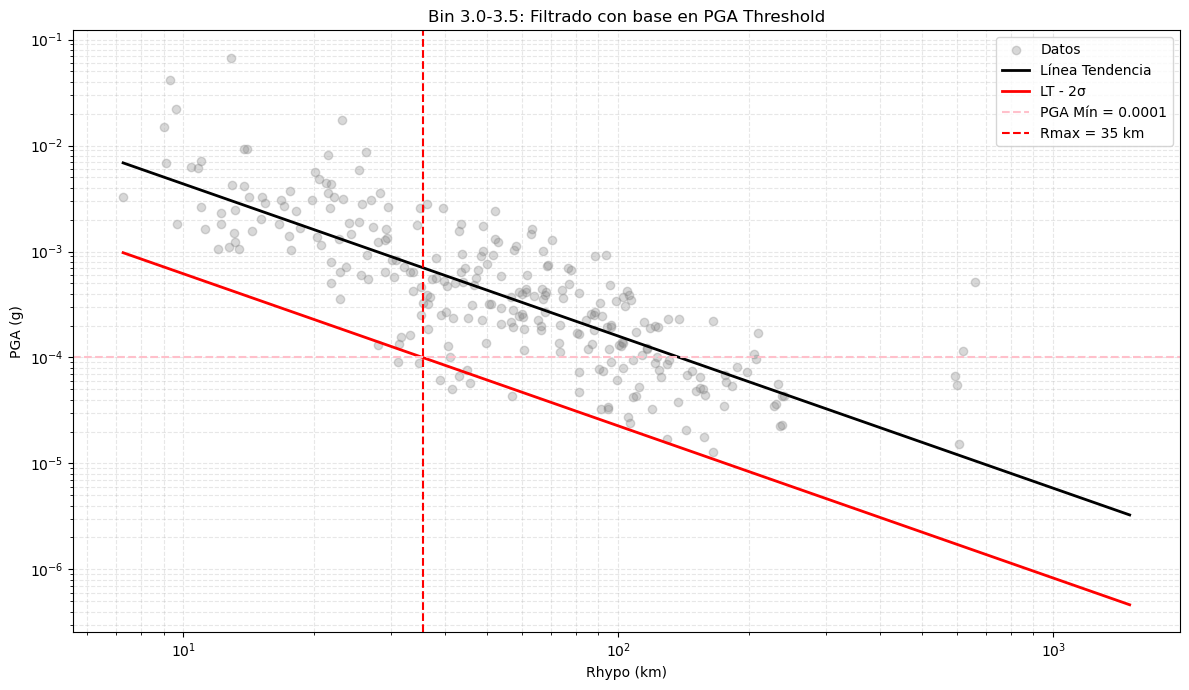

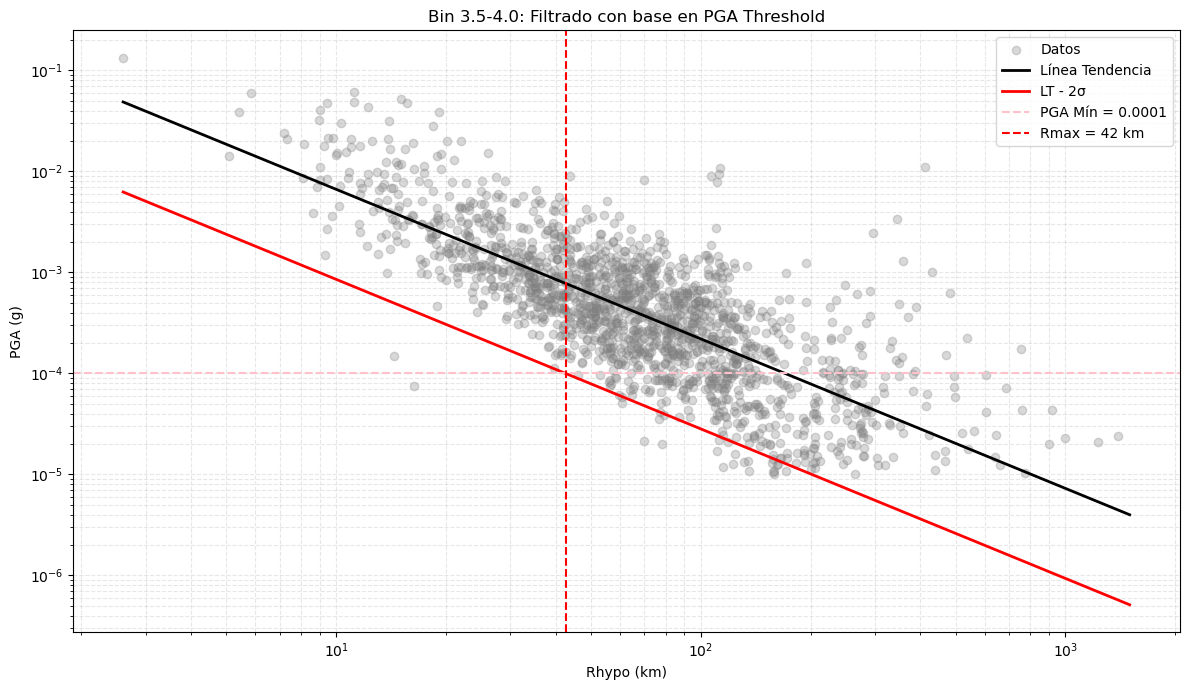

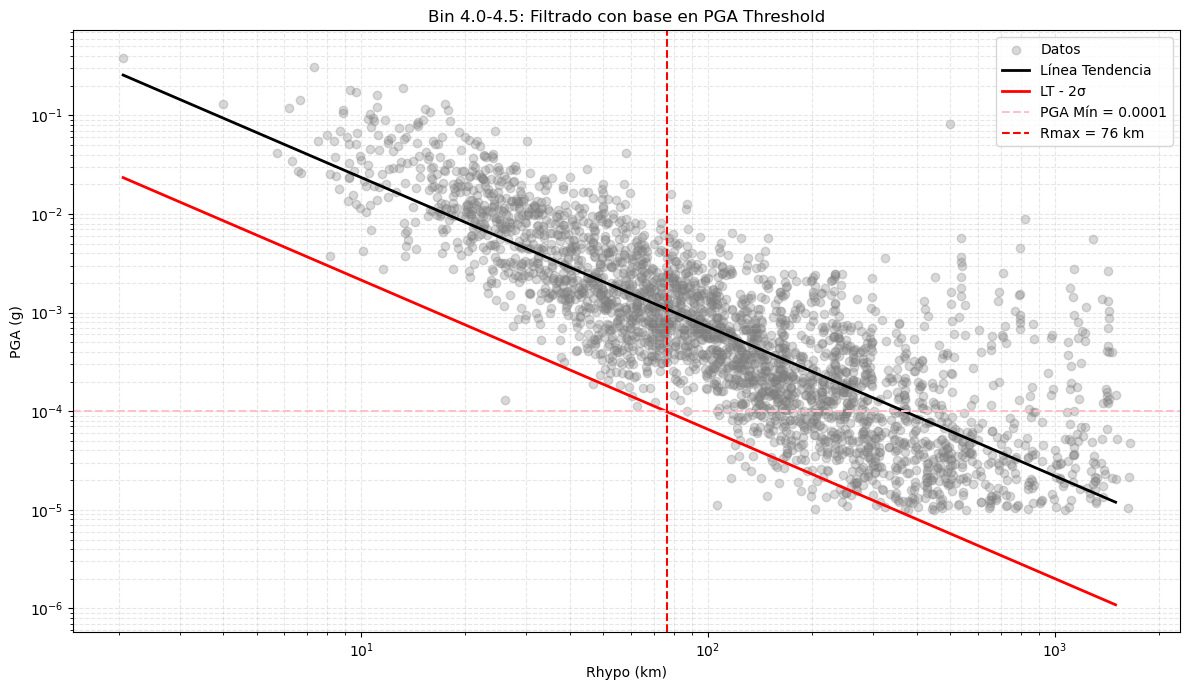

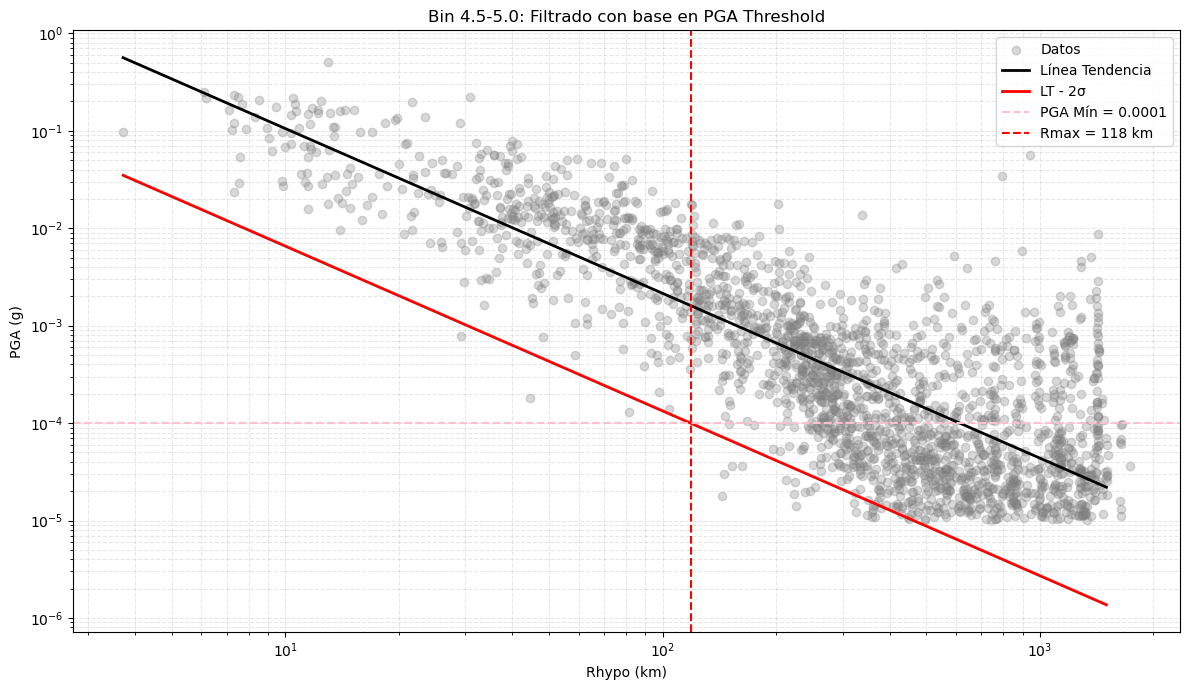

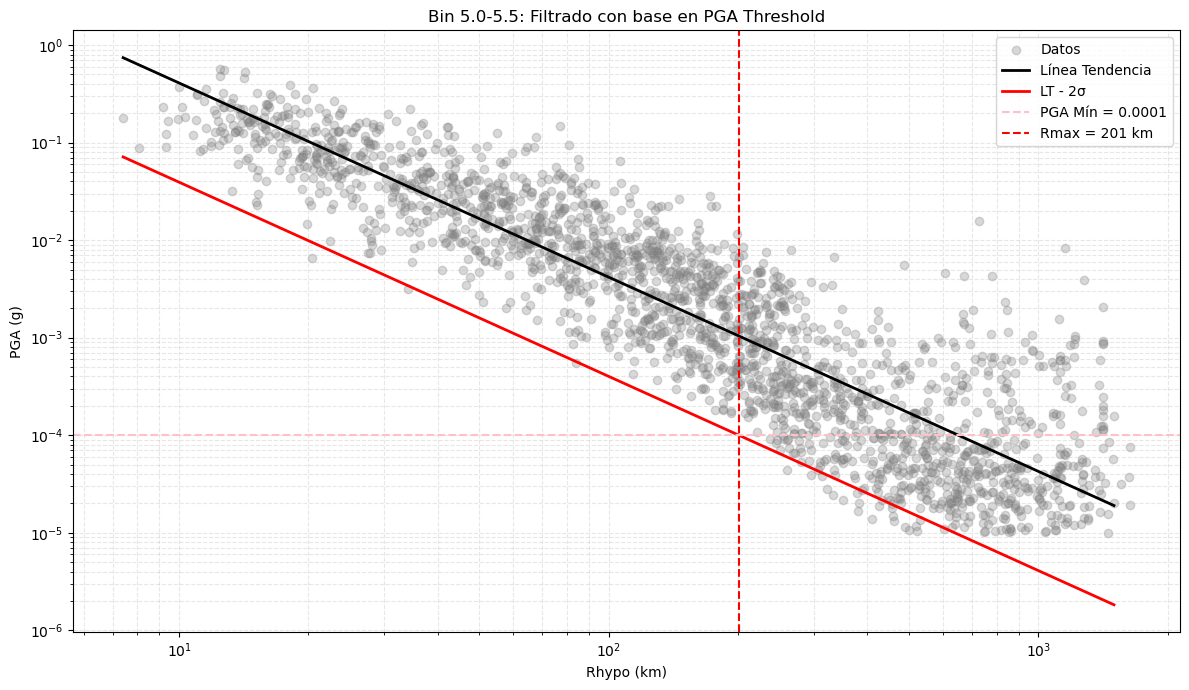

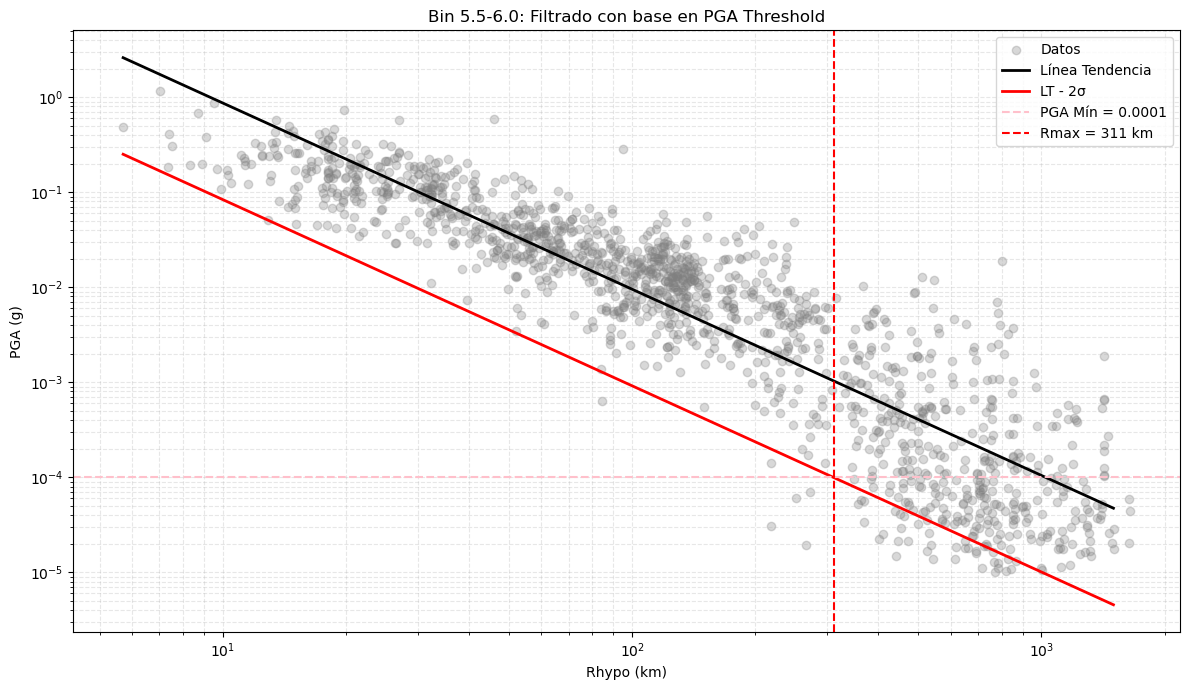

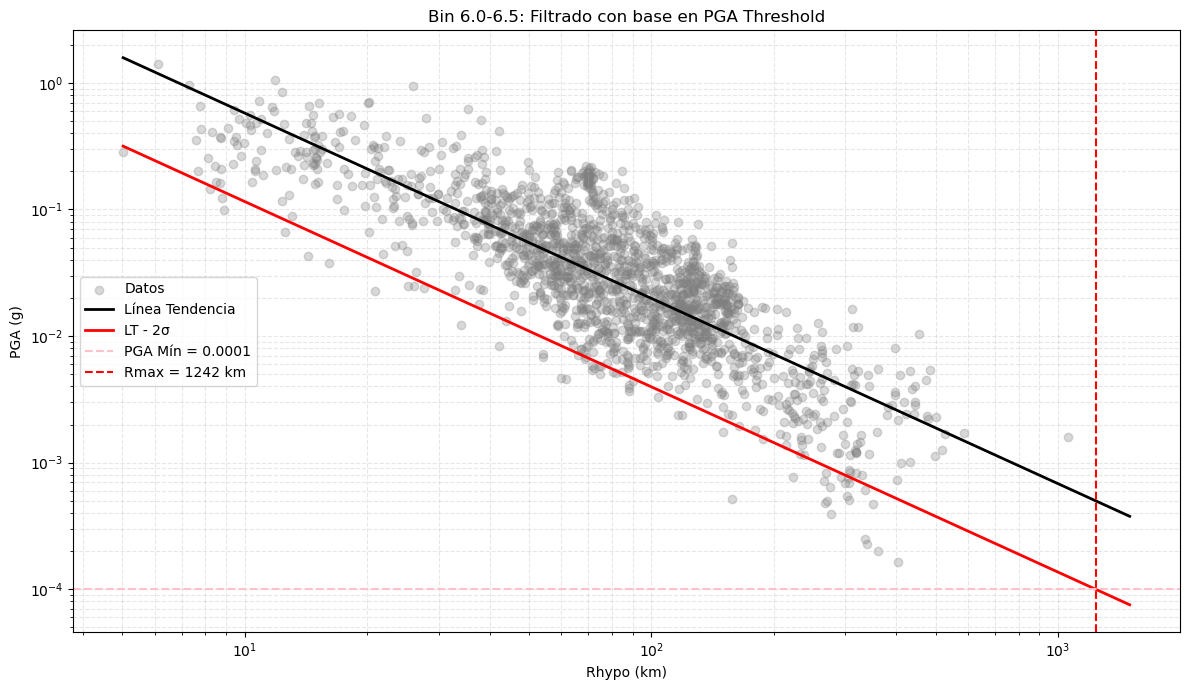

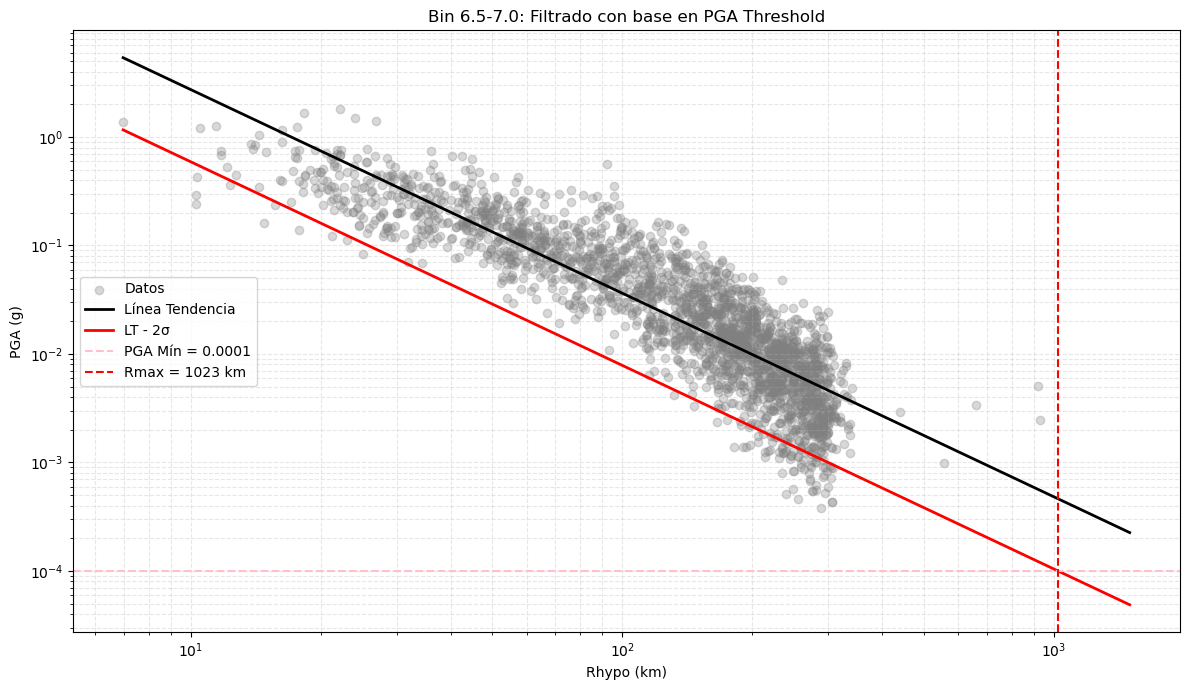

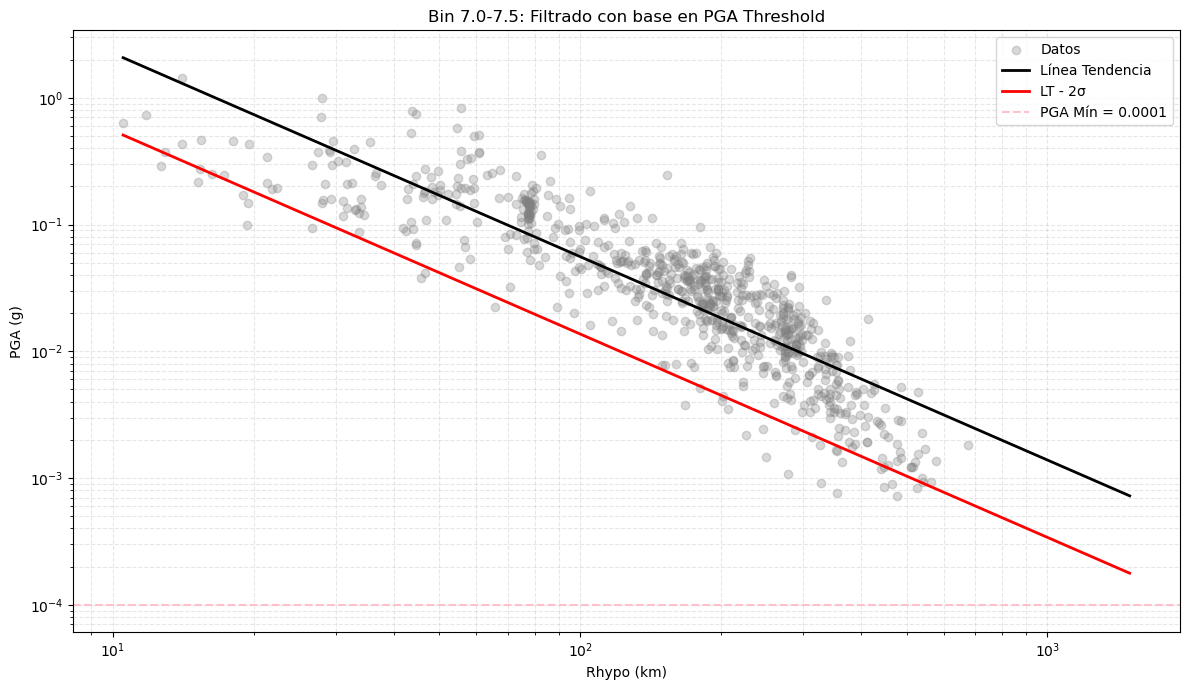

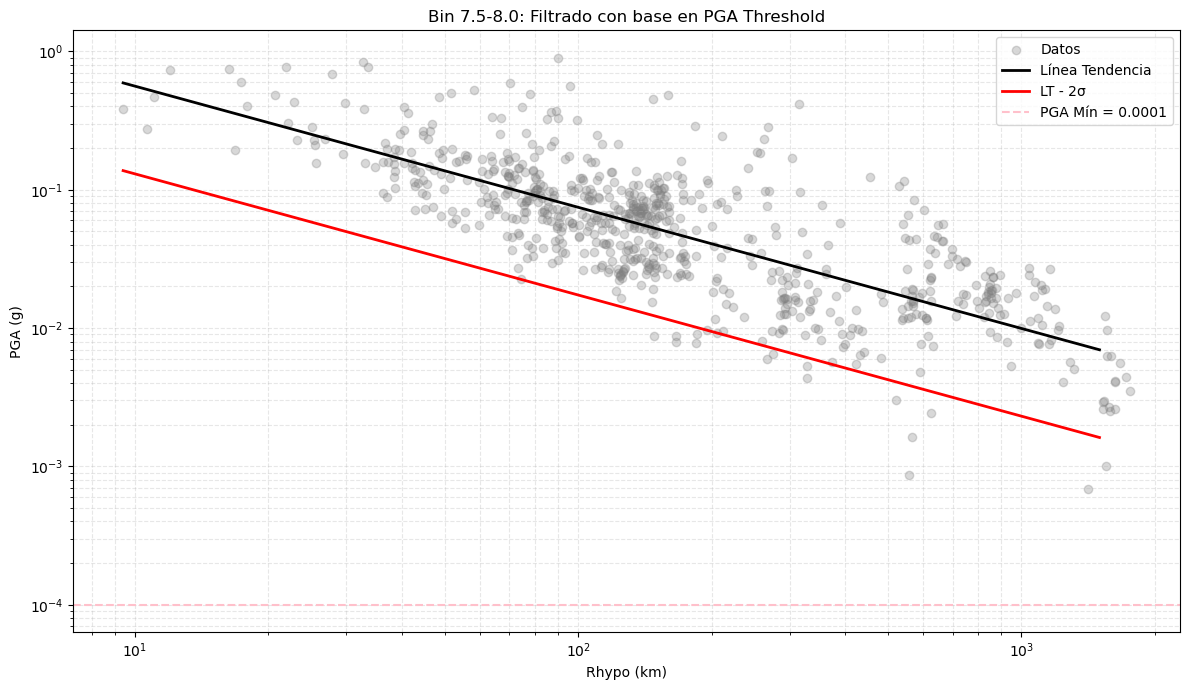

Resultados Rmax por bin:
3.0-3.5: 35.62906404860754
3.5-4.0: 42.79466013240592
4.0-4.5: 76.0450541153358
4.5-5.0: 118.97322286109743
5.0-5.5: 201.11636081673532
5.5-6.0: 311.2590138828386
6.0-6.5: 1242.5723936272595
6.5-7.0: 1023.9824377662434
7.0-7.5: None
7.5-8.0: None


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Definimos función para aplicar tu lógica
def analizar_bin(df, label, pga_min=1e-4, columna_x="Rhypo_OpenQuake", columna_y="T_0.01_RotD50"):
    x = df[columna_x]
    y = df[columna_y]
    
    # Filtrar datos sin NA y aplicar log10
    x_log = np.log10(x)
    y_log = np.log10(y)
    mask = (x_log.notna()) & (y_log.notna())
    x_log = x_log[mask].values.reshape(-1, 1)
    y_log = y_log[mask].values
    
    if len(x_log) < 10:  # evitar bins vacíos
        print(f"Bin {label} sin suficientes datos.")
        return None
    
    # Modelo de regresión lineal (log-log)
    modelo = LinearRegression()
    modelo.fit(x_log, y_log)
    
    # Línea de tendencia
    x_pred = np.logspace(np.log10(x.min()), np.log10(1500), 1000)
    x_pred_log = np.log10(x_pred).reshape(-1, 1)
    y_pred_log = modelo.predict(x_pred_log)
    
    # Desviación estándar de los residuos (hasta 20,000 km)
    residuos = y_log - modelo.predict(x_log)
    residuos_limite = residuos[x[mask].values <= 20000]
    sigma = np.std(residuos_limite)
    y_pred_log_2sigma = y_pred_log - 2 * sigma
    
    # Calcular intersección con PGA mínimo
    pga_min_log = np.log10(pga_min)
    idx_interseccion = np.where(y_pred_log_2sigma <= pga_min_log)[0]
    R_max = x_pred[idx_interseccion[0]] if len(idx_interseccion) > 0 else None
    
    # --- Gráfico ---
    plt.figure(figsize=(12, 7))
    plt.scatter(x, y, alpha=0.3, label="Datos", color='gray')
    plt.plot(x_pred, 10**y_pred_log, color='black', label="Línea Tendencia", linewidth=2)
    plt.plot(x_pred, 10**y_pred_log_2sigma, color='red', label="LT - 2σ", linewidth=2)
    plt.axhline(y=pga_min, color='pink', linestyle='--', label=f"PGA Mín = {pga_min:g}")
    
    if R_max:
        plt.axvline(x=R_max, color='red', linestyle='--', label=f"Rmax = {int(R_max)} km")
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Rhypo (km)")
    plt.ylabel("PGA (g)")
    plt.title(f"Bin {label}: Filtrado con base en PGA Threshold")
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return R_max

# --- Diccionario con tus dataframes ---
bins_dict = {
    "3.0-3.5": df_30_35,
    "3.5-4.0": df_35_40,
    "4.0-4.5": df_40_45,
    "4.5-5.0": df_45_50,
    "5.0-5.5": df_50_55,
    "5.5-6.0": df_55_60,
    "6.0-6.5": df_60_65,
    "6.5-7.0": df_65_70,
    "7.0-7.5": df_70_75,
    "7.5-8.0": df_75_80
}

# --- Iterar sobre todos los bins ---
Rmax_results = {}
for label, df_bin in bins_dict.items():
    Rmax_results[label] = analizar_bin(df_bin, label)

# Ver resultados
print("Resultados Rmax por bin:")
for label, rmax in Rmax_results.items():
    print(f"{label}: {rmax}")


In [23]:
# Filtrar cada bin con su respectivo Rmax
df30_35 = df_30_35[df_30_35['Rhypo_OpenQuake'] <= Rmax_results["3.0-3.5"]]
df35_40 = df_35_40[df_35_40['Rhypo_OpenQuake'] <= Rmax_results["3.5-4.0"]]
df40_45 = df_40_45[df_40_45['Rhypo_OpenQuake'] <= Rmax_results["4.0-4.5"]]
df45_50 = df_45_50[df_45_50['Rhypo_OpenQuake'] <= Rmax_results["4.5-5.0"]]
df50_55 = df_50_55[df_50_55['Rhypo_OpenQuake'] <= Rmax_results["5.0-5.5"]]
df55_60 = df_55_60[df_55_60['Rhypo_OpenQuake'] <= Rmax_results["5.5-6.0"]]
df60_65 = df_60_65[df_60_65['Rhypo_OpenQuake'] <= Rmax_results["6.0-6.5"]]
df65_70 = df_65_70[df_65_70['Rhypo_OpenQuake'] <= Rmax_results["6.5-7.0"]]
#df70_75 = df_70_75[df_70_75['Rhypo_OpenQuake'] <= Rmax_results["7.0-7.5"]]
#df75_80 = df_75_80[df_75_80['Rhypo_OpenQuake'] <= Rmax_results["7.5-8.0"]]
df70_75 = df_70_75
df75_80 = df_75_80
# Concatenar todos los bins ya filtrados
df_total2 = pd.concat(
    [df30_35, df35_40, df40_45, df45_50, df50_55,
     df55_60, df60_65, df65_70, df70_75, df75_80],
    ignore_index=True
)

# Copiar y aplicar filtro final de PGA
df_total = df_total2.copy()
df_total = df_total[df_total['T_0.01_RotD50'] > 1e-4]



In [24]:
df_total

,Hypocenter Depth (km),Magnitude,Rhypo_OpenQuake,Rrup_OpenQuake,Soil_Class,Tmax,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_0.75_RotD50,T_1.0_RotD50,T_1.5_RotD50,T_2.0_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_10.0_RotD50,origen
0,7.213,3.4,12.75630,12.22,2,0.808081,0.001092,0.001078,0.001453,0.002399,...,0.000467,0.000183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
1,7.213,3.4,27.33596,27.03,3,1.081081,0.001714,0.001696,0.001745,0.002034,...,0.000513,0.000254,0.000067,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
2,7.213,3.4,35.07003,34.85,3,1.081081,0.002577,0.002538,0.002716,0.003008,...,0.000491,0.000322,0.000082,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
3,7.213,3.4,20.55230,20.07,3,1.333333,0.004874,0.005332,0.006315,0.008871,...,0.000329,0.000171,0.000060,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
4,8.469,3.4,12.84512,12.51,3,1.666667,0.067464,0.071776,0.104458,0.115679,...,0.001890,0.001022,0.000448,0.000245,NaN,NaN,NaN,NaN,NaN,NGAW2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10241,10.040,7.9,609.00000,441.95,3,20.000000,0.011848,0.011885,0.011950,0.012048,...,0.016969,0.013162,0.011378,0.012016,0.007713,0.007323,0.009168,0.011108,0.005309,NGAW2
10242,10.040,7.9,537.99000,362.18,3,26.666667,0.013792,0.013822,0.013872,0.013959,...,0.025694,0.023990,0.015413,0.018298,0.011543,0.008223,0.008980,0.008458,0.005573,NGAW2
10243,10.040,7.9,540.10000,376.08,2,26.666667,0.011857,0.011864,0.011873,0.011891,...,0.027657,0.025381,0.019319,0.020109,0.007606,0.005916,0.006102,0.008619,0.006396,NGAW2
10244,10.040,7.9,556.05000,416.48,3,13.333333,0.011815,0.011839,0.011880,0.011948,...,0.014408,0.019274,0.011439,0.008004,0.006273,0.004877,0.004101,0.006534,0.004158,NGAW2


In [25]:
df_total.drop(columns=['Rhypo_OpenQuake'], inplace=True)

In [26]:
df_total[Sa_Crustal]=np.log(df_total[Sa_Crustal])
df_total["Rrup_OpenQuake"]=np.log(df_total["Rrup_OpenQuake"])

## Preprocesamiento 

Se usarán modelos de naturalezas distintas para probar las eficacias, precisiones y capacidad de extrapolación de cada uno.

Ridge (lineal)<br>
SVR (kernel)<br>
Random Forest o XGBoost (árboles)<br>
KNN (instancia)<br>
Naive Bayes (probabilístico)<br>
MLP (neuronal)<br>

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [28]:
inputs = ['Magnitude', 'Rrup_OpenQuake', 'Hypocenter Depth (km)', 'Soil_Class','origen']
outputs = Sa_Crustal
num_features = ['Magnitude', 'Rrup_OpenQuake', 'Hypocenter Depth (km)']
cat_features = ['Soil_Class', 'origen']
df_total[cat_features] = df_total[cat_features].astype(str)
X = df_total[inputs]
y = df_total[Sa_Crustal]

In [29]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=0, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=0, shuffle=True
)

In [30]:
num_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

cat_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features)
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [31]:
X_train_feats = pre.fit_transform(X_train)
X_val_feats   = pre.transform(X_val)
X_test_feats  = pre.transform(X_test)
X_val_test_feats  = np.vstack([X_val_feats, X_test_feats])
Y_val_test_feats  = pd.concat([y_val, y_test], ignore_index=True)

In [32]:

print(len(X_val_feats))
print(len(X_test_feats))
print(len(X_val_test_feats))
print(len(Y_val_test_feats))

1536
1536
3072
3072


## Modelamiento

In [33]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV


In [34]:
from sklearn.base import clone

def make_estimator(choice: str, params: dict = None, random_state: int = 0):
    """
    Fabrica de estimadores para regresión.
    choices soportados:
      "ridge", "lasso", "elasticnet"/"enet", "linear"/"ols"
      "svr"/"svm"
      "rf"/"random_forest"/"randomforest"
      "xgb"/"xgboost"
      "knn"
      "bayes"   -> BayesianRidge (probabilístico)
      "mlp"/"nn"/"mlpregressor"
      (opcionales) "gbrt"/"gboost"/"gradient_boosting", "catboost"/"cat"
    """
    params = params or {}
    choice = choice.lower()

    # Lineales
    if choice in ["ridge", "lasso", "linear"]:
        if choice == "ridge":
            from sklearn.linear_model import Ridge
            return Ridge(**params)
        elif choice == "lasso":
            from sklearn.linear_model import Lasso
            return Lasso(**params)
        else:
            from sklearn.linear_model import LinearRegression
            return LinearRegression(**params)

    # Kernel SVM
    if choice in ["svr", "svm"]:
        from sklearn.svm import SVR
        return SVR(**params)

    # Árboles
    if choice in ["rf", "random_forest", "randomforest"]:
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(random_state=random_state, **params)



    # KNN
    if choice in ["knn"]:
        from sklearn.neighbors import KNeighborsRegressor
        return KNeighborsRegressor(**params)

    # Probabilístico (regresión): Bayesian Ridge
    if choice in ["bayes", "bayesian", "bayesianridge"]:
        from sklearn.linear_model import BayesianRidge
        return BayesianRidge(**params)

    # Neuronal
    if choice in ["mlp", "nn", "mlpregressor"]:
        from sklearn.neural_network import MLPRegressor
        return MLPRegressor(random_state=random_state, **params)

    raise ValueError(f"Modelo no reconocido: {choice}")



In [35]:
def _resolve_per_column(spec, col):
    """
    Si spec es un dict por columna y existe la clave 'col', devuelve eso.
    Si es un dict de hiperparámetros global (sin la clave 'col'), devuelve el dict completo.
    """
    if isinstance(spec, dict):
        return spec.get(col, spec)   # <<--- cambio clave: antes devolvías None
    return spec



In [36]:
def entrenar_modelos_por_columna(
    X_train, y_train, X_test, y_test,
    *,
    col_names=None,
    model_choice="svr",            # str | sklearn estimator | {col: str/estimator}
    model_params=None,             # dict | {col: dict}
    grid=None,                     # None o dict con keys: param_grid, cv, scoring, n_jobs, refit
    random_state=0,
    verbose=False
):
    # Resolver nombres de columnas del target
    if isinstance(y_train, np.ndarray):
        if col_names is None:
            raise ValueError("Cuando y_train es ndarray debes pasar col_names=[...].")
        y_train = pd.DataFrame(y_train, columns=col_names)
        y_test = pd.DataFrame(y_test, columns=col_names)
        col_names = list(col_names)
    else:
        col_names = list(y_train.columns) if col_names is None else list(col_names)

    dict_modelos = {}
    filas_metricas = []

    for col in col_names:
        # Filtrado por NaN específico de la columna objetivo
        mask_train = ~y_train[col].isna()
        mask_test  = ~y_test[col].isna()

        X_tr = X_train[mask_train]
        y_tr = y_train[col][mask_train]
        X_te = X_test[mask_test]
        y_te = y_test[col][mask_test]

        # Resolver elección de modelo y parámetros para esta columna
        choice_col = _resolve_per_column(model_choice, col)
        params_col = _resolve_per_column(model_params, col) or {}

        # Admite un estimador ya instanciado, o un string de la fábrica
        if hasattr(choice_col, "fit"):
            base_estimator = choice_col
        else:
            base_estimator = make_estimator(choice_col, params_col, random_state=random_state)

        # Clonar para no compartir estado entre columnas
        estimator = clone(base_estimator)

        # ¿GridSearchCV?
        if grid is not None:
            gs_kwargs = {
                "param_grid": grid.get("param_grid", {}),
                "cv": grid.get("cv", 3),
                "scoring": grid.get("scoring", None),
                "n_jobs": grid.get("n_jobs", None),
                "refit": grid.get("refit", True),
            }
            estimator = GridSearchCV(estimator, **gs_kwargs)

        # Entrenar
        estimator.fit(X_tr, y_tr)

        # Guardar el mejor estimador si hubo grid
        final_model = estimator.best_estimator_ if isinstance(estimator, GridSearchCV) else estimator
        dict_modelos[col] = final_model

        # ----- Predicción y métricas TEST -----
        y_pred = final_model.predict(X_te)
        r2    = r2_score(y_te, y_pred)
        mse   = mean_squared_error(y_te, y_pred)
        rmse  = np.sqrt(mse)
        mae   = mean_absolute_error(y_te, y_pred)
        # MAPE (manejo de inf si hay ceros)
        mape  = mean_absolute_percentage_error(y_te, y_pred)
        if np.isinf(mape):
            mape = np.nan

        # ----- Métricas TRAIN (útil para ver overfitting) -----
        y_pred_tr = final_model.predict(X_tr)
        r2_tr    = r2_score(y_tr, y_pred_tr)
        mse_tr   = mean_squared_error(y_tr, y_pred_tr)
        rmse_tr  = np.sqrt(mse_tr)
        mae_tr   = mean_absolute_error(y_tr, y_pred_tr)
        mape_tr  = mean_absolute_percentage_error(y_tr, y_pred_tr)
        if np.isinf(mape_tr):
            mape_tr = np.nan

        if verbose:
            nombre_modelo = type(final_model).__name__
            print(f"[{col}] {nombre_modelo} | Test  -> R2:{r2:.3f} RMSE:{rmse:.3f} MSE:{mse:.4f} MAE:{mae:.3f} MAPE:{(mape*100):.2f}%")
            print(f"[{col}] {nombre_modelo} | Train -> R2:{r2_tr:.3f} RMSE:{rmse_tr:.3f} MSE:{mse_tr:.4f} MAE:{mae_tr:.3f} MAPE:{(mape_tr*100):.2f}%")
            if isinstance(estimator, GridSearchCV):
                print(f"   Best params: {estimator.best_params_}")

        filas_metricas.append({
            "columna": col,
            "R2_test": r2,     "RMSE_test": rmse,  "MSE_test": mse,   "MAE_test": mae,  # "MAPE_test": mape,
            "R2_train": r2_tr, "RMSE_train": rmse_tr, "MSE_train": mse_tr, "MAE_train": mae_tr, #"MAPE_train": mape_tr,
            "modelo": type(final_model).__name__
        })

    df_metricas = pd.DataFrame(filas_metricas).set_index("columna").sort_index()
    return dict_modelos, df_metricas


In [37]:
def predecir_por_periodo(dict_modelos, X, periodo, *, prec=3):
        # mapea cada clave existente a su T numérico
    key_map = {float(k.split('_')[1]): k for k in dict_modelos}
    if periodo not in key_map:
        raise ValueError(f"Período {periodo}s no entrenado.")
    key   = key_map[periodo]
    model = dict_modelos[key]
    return model.predict(X).ravel()

def pred_interpolado(dict_modelos, X, periodo):
    # lista de periodos entrenados
    keys = sorted(dict_modelos.keys(), key=lambda k: float(k.split('_')[1]))
    T_vals = np.array([float(k.split('_')[1]) for k in keys])

    if periodo < T_vals[0] or periodo > T_vals[-1]:
        raise ValueError("Periodo fuera del rango entrenado; no se puede interpolar.")

    # encuentra los dos vecinos
    idx_hi = np.searchsorted(T_vals, periodo)
    idx_lo = idx_hi - 1
    T_lo, T_hi = T_vals[idx_lo], T_vals[idx_hi]
    w = (np.log(periodo) - np.log(T_lo)) / (np.log(T_hi) - np.log(T_lo))

    # predicciones en ln-Sa
    Sa_lo = np.log(dict_modelos[keys[idx_lo]].predict(X).ravel())
    Sa_hi = np.log(dict_modelos[keys[idx_hi]].predict(X).ravel())

    Sa_interp = np.exp((1 - w) * Sa_lo + w * Sa_hi)
    return Sa_interp


In [ ]:
"""# y_train / y_test son DataFrames con columnas = periodos (p.ej. "0.10","0.20",...)
modelosSVR, metricasSVR = entrenar_modelos_por_columna(
    X_train_feats,y_train, X_val_test_feats, Y_val_test_feats,
    model_choice="svr",
    model_params={"kernel":"linear", "C":1, "epsilon":0.1},
    verbose=True
)

print(type(modelosSVR["T_0.01_RotD50"]))  # estimador entrenado para la columna "0.10""""


[T_0.01_RotD50] SVR | Test  -> R2:0.823 RMSE:0.706 MSE:0.4989 MAE:0.547 MAPE:19.64%
[T_0.01_RotD50] SVR | Train -> R2:0.839 RMSE:0.684 MSE:0.4677 MAE:0.519 MAPE:22.54%
[T_0.02_RotD50] SVR | Test  -> R2:0.824 RMSE:0.706 MSE:0.4979 MAE:0.546 MAPE:19.02%
[T_0.02_RotD50] SVR | Train -> R2:0.839 RMSE:0.685 MSE:0.4698 MAE:0.521 MAPE:19.25%
[T_0.03_RotD50] SVR | Test  -> R2:0.823 RMSE:0.710 MSE:0.5040 MAE:0.550 MAPE:99.14%
[T_0.03_RotD50] SVR | Train -> R2:0.838 RMSE:0.692 MSE:0.4788 MAE:0.526 MAPE:19.00%
[T_0.04_RotD50] SVR | Test  -> R2:0.821 RMSE:0.717 MSE:0.5137 MAE:0.555 MAPE:25.20%
[T_0.04_RotD50] SVR | Train -> R2:0.835 RMSE:0.700 MSE:0.4906 MAE:0.533 MAPE:27.18%
[T_0.05_RotD50] SVR | Test  -> R2:0.818 RMSE:0.726 MSE:0.5269 MAE:0.561 MAPE:23.86%
[T_0.05_RotD50] SVR | Train -> R2:0.830 RMSE:0.714 MSE:0.5095 MAE:0.543 MAPE:35.31%
[T_0.075_RotD50] SVR | Test  -> R2:0.803 RMSE:0.763 MSE:0.5817 MAE:0.590 MAPE:39.85%
[T_0.075_RotD50] SVR | Train -> R2:0.815 RMSE:0.750 MSE:0.5632 MAE:0.571 MA

In [ ]:
#metricasSVR

,R2_test,RMSE_test,MSE_test,MAE_test,R2_train,RMSE_train,MSE_train,MAE_train,modelo
columna,,,,,,,,,
T_0.01_RotD50,0.823107,0.706300,0.498860,0.546997,0.839411,0.683868,0.467675,0.519318,SVR
T_0.02_RotD50,0.824129,0.705647,0.497937,0.545933,0.839485,0.685392,0.469762,0.520957,SVR
T_0.03_RotD50,0.823225,0.709899,0.503957,0.549585,0.837633,0.691956,0.478803,0.526139,SVR
T_0.04_RotD50,0.821316,0.716711,0.513674,0.555460,0.835024,0.700428,0.490599,0.533233,SVR
T_0.05_RotD50,0.818305,0.725904,0.526936,0.561488,0.830411,0.713803,0.509515,0.542882,SVR
T_0.075_RotD50,0.802718,0.762711,0.581729,0.589949,0.815270,0.750442,0.563163,0.570845,SVR
T_0.15_RotD50,0.794241,0.777253,0.604123,0.601714,0.816065,0.744996,0.555019,0.569621,SVR
T_0.1_RotD50,0.794709,0.780785,0.609625,0.603776,0.810400,0.759585,0.576970,0.579907,SVR
T_0.25_RotD50,0.804210,0.759103,0.576238,0.594256,0.827461,0.721267,0.520226,0.553455,SVR


In [ ]:
"""# Ejemplo de un solo evento (DataFrame de 1 fila)
nuevo_evento = pd.DataFrame([{
    "Hypocenter Depth (km)": 10,
    "Magnitude": 6.5,
    "Soil_Class": "2",
    "Rrup_OpenQuake": 15,
    'origen': 'Colombia'
}])
"""

In [ ]:
"""import re

# Extrae los valores de periodo (float) desde nombres como "T_0.01_RotD50"
periodos = np.array([
    float(re.search(r"T_(\d+\.\d+)", col).group(1))
    for col in modelosSVR.keys()
])

# Ordenar los periodos (muy importante para graficar)
orden = np.argsort(periodos)
periodos = periodos[orden]

# Guardamos también los nombres de columna en ese mismo orden
cols_ordenadas = np.array(list(modelosSVR.keys()))[orden]
"""

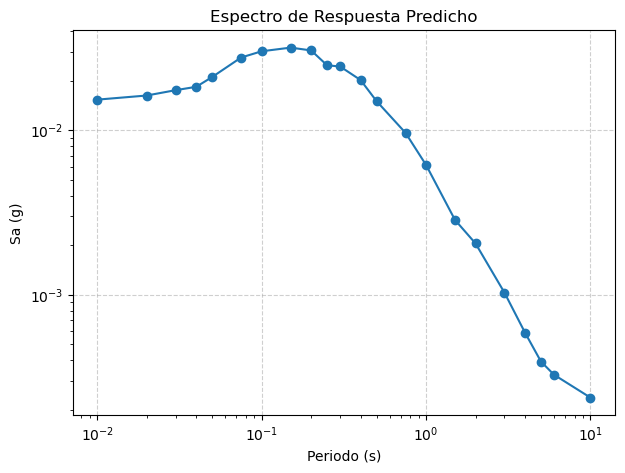

In [ ]:
"""# 3) Transformar con el MISMO preprocesador ya entrenado
X_new = pre.transform(nuevo_evento)   # <- Ojo: el mismo 'pre' que usaste en train

# 4) Predecir Sa para cada periodo y graficar
Sa_pred = [modelosSVR[col].predict(X_new)[0] for col in cols_ordenadas]
df_pred = pd.DataFrame({"Periodo (s)": periodos, "Sa_pred (g)": Sa_pred})

plt.figure(figsize=(7,5))
plt.plot(df_pred["Periodo (s)"], np.exp(df_pred["Sa_pred (g)"]), marker='o')
plt.xlabel("Periodo (s)"); plt.ylabel("Sa (g)")
plt.xscale("log")
plt.yscale("log")
plt.title("Espectro de Respuesta Predicho"); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()"""

In [43]:
model_choice = {
    "ridge": "ridge",            # Lineal paramétrico
    "svr": "svr",                # Kernel (no lineal)
    "rf": "rf",                  # Árboles (Random Forest)
    "knn": "knn",                # Instancia / Vecindad
    "bayes": "bayes",            # Probabilístico ( Bayesian Ridge)
    "mlp": "mlp"                 # Neuronal (Perceptrón multicapa)
}


In [108]:
model_params = {
    "ridge": {"alpha": 1.0},
    "svr": {"kernel": "linear", "C": 0.1, "epsilon": 0.15, "shrinking": True},
    "rf": {"n_estimators": 100, "max_depth": 5},
    "knn": {"n_neighbors": 5},
    "bayes": {},
    "mlp": {"hidden_layer_sizes": (64, 32),"alpha": 0.001,"max_iter": 200,"learning_rate": "adaptive","learning_rate_init": 0.001,
            "early_stopping": True,"validation_fraction": 0.15}
}



In [109]:
modelos_resultados = {}

for nombre, modelo in model_choice.items():
    params = model_params.get(nombre, {})
    choice = make_estimator(modelo, params, random_state=0)  # instancia lista
    modelos, metricas = entrenar_modelos_por_columna(
        X_train_feats, y_train, X_val_test_feats, Y_val_test_feats,
        model_choice=choice,          # <<--- pasas el estimador ya creado
        verbose=False
    )
    modelos_resultados[nombre] = {"modelos": modelos, "metricas": metricas}



In [110]:
modelos_resultados.items()

dict_items([('ridge', {'modelos': {'T_0.01_RotD50': Ridge(), 'T_0.02_RotD50': Ridge(), 'T_0.03_RotD50': Ridge(), 'T_0.04_RotD50': Ridge(), 'T_0.05_RotD50': Ridge(), 'T_0.075_RotD50': Ridge(), 'T_0.1_RotD50': Ridge(), 'T_0.15_RotD50': Ridge(), 'T_0.2_RotD50': Ridge(), 'T_0.25_RotD50': Ridge(), 'T_0.3_RotD50': Ridge(), 'T_0.4_RotD50': Ridge(), 'T_0.5_RotD50': Ridge(), 'T_0.75_RotD50': Ridge(), 'T_1.0_RotD50': Ridge(), 'T_1.5_RotD50': Ridge(), 'T_2.0_RotD50': Ridge(), 'T_3.0_RotD50': Ridge(), 'T_4.0_RotD50': Ridge(), 'T_5.0_RotD50': Ridge(), 'T_6.0_RotD50': Ridge(), 'T_10.0_RotD50': Ridge()}, 'metricas':                  R2_test  RMSE_test  MSE_test  MAE_test  R2_train  RMSE_train  \
columna                                                                         
T_0.01_RotD50   0.714820   0.896794  0.804240  0.697379  0.735751    0.877245   
T_0.02_RotD50   0.714176   0.899579  0.809242  0.699519  0.735557    0.879727   
T_0.03_RotD50   0.711279   0.907247  0.823097  0.705803  0.732239  

In [111]:
import numpy as np
import pandas as pd

df_comp = pd.concat(
    {
        k: v["metricas"].select_dtypes(include=[np.number]).mean()
        for k, v in modelos_resultados.items()
    },
    axis=1
).T

# Si tus nombres son diferentes (p. ej. R2_test, RMSE_test, MAE_test), ajusta acá:
cols_pref = [c for c in df_comp.columns if any(m in c.lower() for m in ["r2","rmse","mae"])]
df_comp = df_comp[cols_pref]

print(df_comp)



        R2_test  RMSE_test  MAE_test  R2_train  RMSE_train  MAE_train
ridge  0.744379   0.915207  0.719657  0.759554    0.899396   0.711231
svr    0.742171   0.918986  0.717999  0.758316    0.901570   0.709539
rf     0.793501   0.826741  0.653031  0.809055    0.804943   0.633540
knn    0.835282   0.738998  0.564851  0.896296    0.592668   0.450121
bayes  0.744387   0.915196  0.719652  0.759554    0.899396   0.711233
mlp    0.840367   0.727403  0.572804  0.853770    0.704182   0.551319


In [112]:
def extraer_periodo(colname, regex=r"T_([0-9]*\.?[0-9]+)"):
    m = re.search(regex, str(colname))
    return float(m.group(1)) if m else np.nan

filas = []
for nombre, pack in modelos_resultados.items():
    met = pack["metricas"].copy()   # DataFrame de métricas por columna (periodo)

    # Reset del índice de forma robusta (independiente del nombre del índice)
    try:
        # pandas >= 1.3
        met = met.reset_index(names="col")
    except TypeError:
        # pandas < 1.3
        idx_name = met.index.name or "index"
        met = met.reset_index().rename(columns={idx_name: "col"})

    # Extrae el periodo desde nombres tipo "T_0.01_RotD50"
    met["Periodo (s)"] = met["col"].map(extraer_periodo)
    met["modelo"] = nombre

    # Nos quedamos con columnas numéricas (R2/RMSE/MAE...) + identificadores
    metric_cols = met.select_dtypes(include=[np.number]).columns.tolist()
    #met = met[["modelo", "Periodo (s)"] + metric_cols]

    filas.append(met)

df_largo = pd.concat(filas, ignore_index=True).sort_values(["Periodo (s)","modelo"])
df_largo

,col,R2_test,RMSE_test,MSE_test,MAE_test,R2_train,RMSE_train,MSE_train,MAE_train,modelo,Periodo (s)
88,T_0.01_RotD50,0.714829,0.896780,0.804215,0.697374,0.735751,0.877245,0.769560,0.686802,bayes,0.01
66,T_0.01_RotD50,0.824945,0.702621,0.493676,0.535666,0.887990,0.571140,0.326200,0.429743,knn,0.01
110,T_0.01_RotD50,0.830250,0.691892,0.478714,0.542767,0.841378,0.679667,0.461948,0.527785,mlp,0.01
44,T_0.01_RotD50,0.772472,0.801033,0.641654,0.626134,0.792536,0.777294,0.604186,0.605563,rf,0.01
0,T_0.01_RotD50,0.714820,0.896794,0.804240,0.697379,0.735751,0.877245,0.769558,0.686795,ridge,0.01
...,...,...,...,...,...,...,...,...,...,...,...
82,T_10.0_RotD50,0.863759,0.662324,0.438673,0.489612,0.913621,0.526674,0.277385,0.391680,knn,10.00
126,T_10.0_RotD50,0.875582,0.632934,0.400605,0.494913,0.887151,0.601988,0.362389,0.468474,mlp,10.00
60,T_10.0_RotD50,0.845037,0.706366,0.498953,0.559071,0.850015,0.694003,0.481640,0.546482,rf,10.00
16,T_10.0_RotD50,0.786811,0.828512,0.686432,0.669679,0.777344,0.845580,0.715006,0.686822,ridge,10.00


In [113]:
df_ridge = df_largo[df_largo["modelo"] == "ridge"].copy()
df_svr   = df_largo[df_largo["modelo"] == "svr"].copy()
df_rf    = df_largo[df_largo["modelo"] == "rf"].copy()
df_knn   = df_largo[df_largo["modelo"] == "knn"].copy()
df_bayes = df_largo[df_largo["modelo"] == "bayes"].copy()
df_mlp   = df_largo[df_largo["modelo"] == "mlp"].copy()


In [114]:
df_bayes.describe()

,R2_test,RMSE_test,MSE_test,MAE_test,R2_train,RMSE_train,MSE_train,MAE_train,Periodo (s)
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.744387,0.915196,0.839215,0.719652,0.759554,0.899396,0.810065,0.711233,1.607955
std,0.056827,0.041347,0.075604,0.028891,0.050259,0.034736,0.063284,0.023762,2.559550
min,0.668187,0.828512,0.686433,0.669674,0.688369,0.845580,0.715005,0.681764,0.010000
25%,0.700102,0.897476,0.805465,0.699150,0.720446,0.879834,0.774108,0.695250,0.081250
50%,0.723153,0.914352,0.836040,0.717990,0.743007,0.889486,0.791185,0.707660,0.350000
75%,0.801360,0.934629,0.873532,0.732144,0.803340,0.917871,0.842513,0.720627,1.875000
max,0.837998,0.992642,0.985338,0.776297,0.838830,0.973819,0.948323,0.765948,10.000000


In [115]:
df_ridge.describe()

,R2_test,RMSE_test,MSE_test,MAE_test,R2_train,RMSE_train,MSE_train,MAE_train,Periodo (s)
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.744379,0.915207,0.839237,0.719657,0.759554,0.899396,0.810064,0.711231,1.607955
std,0.056835,0.041359,0.075627,0.028894,0.050259,0.034736,0.063283,0.023759,2.559550
min,0.668164,0.828512,0.686432,0.669679,0.688370,0.845580,0.715006,0.681770,0.010000
25%,0.700086,0.897490,0.805491,0.699153,0.720447,0.879833,0.774107,0.695246,0.081250
50%,0.723146,0.914355,0.836047,0.717992,0.743007,0.889486,0.791185,0.707658,0.350000
75%,0.801361,0.934651,0.873574,0.732146,0.803340,0.917870,0.842511,0.720621,1.875000
max,0.838000,0.992677,0.985407,0.776304,0.838829,0.973817,0.948320,0.765940,10.000000


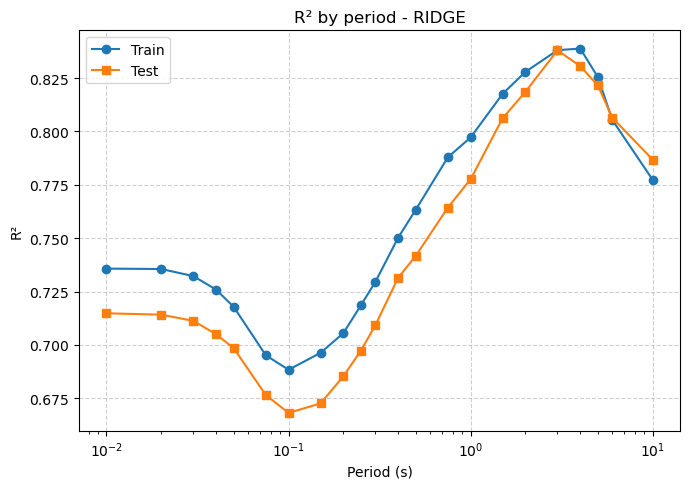

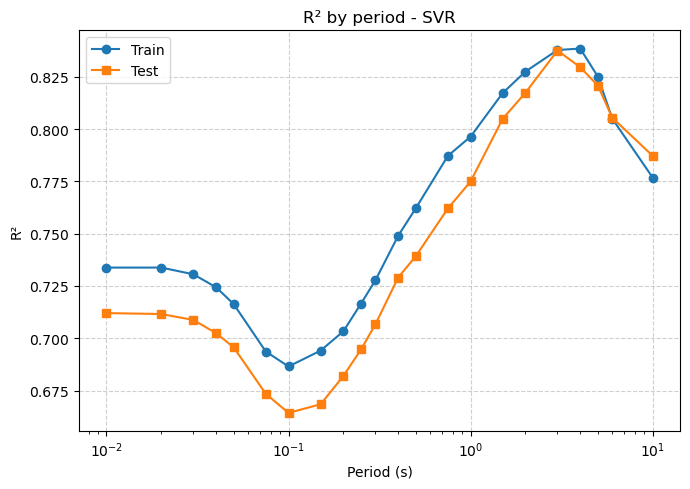

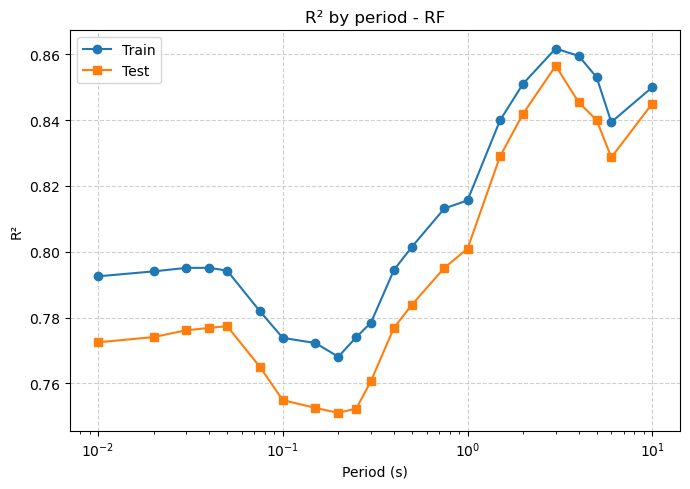

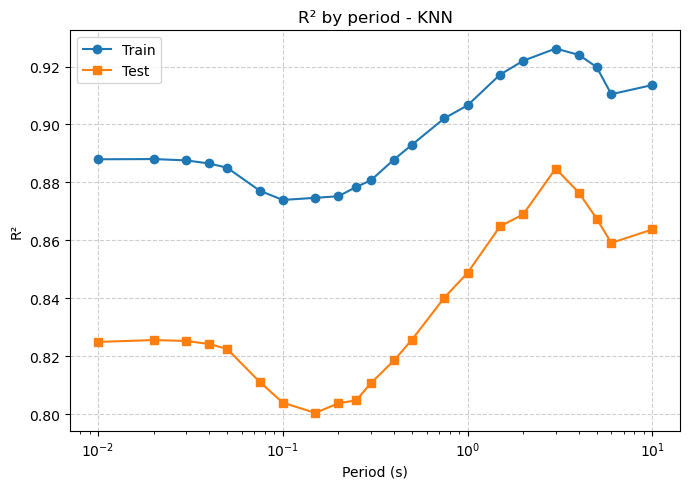

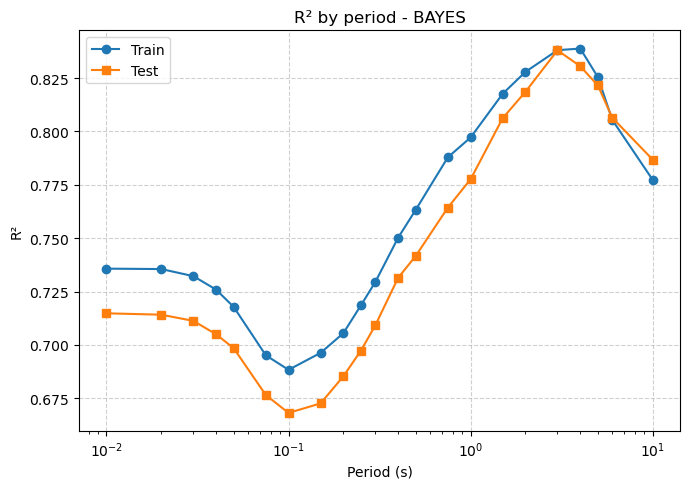

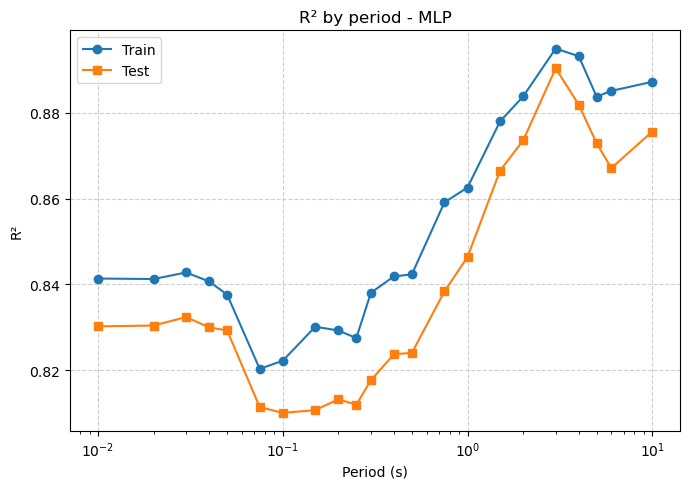

In [116]:
# Dicc con todos tus df
dfs_modelos = {
    "ridge": df_ridge,
    "svr": df_svr,
    "rf": df_rf,
    #"xgb": df_xgb,
    "knn": df_knn,
    "bayes": df_bayes,
    "mlp": df_mlp
}

for nombre, df in dfs_modelos.items():
    plt.figure(figsize=(7, 5))
    df = df.sort_values("Periodo (s)")

    if "R2_train" in df.columns and "R2_test" in df.columns:
        plt.plot(df["Periodo (s)"], df["R2_train"], label="Train", marker='o')
        plt.plot(df["Periodo (s)"], df["R2_test"], label="Test", marker='s')
    else:
        print(f"⚠️  {nombre}: no se encontraron columnas R2_train y R2_test")
        continue
    plt.xscale("log")
    plt.xlabel("Period (s)")
    plt.ylabel("R²")
    plt.title(f"R² by period - {nombre.upper()}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

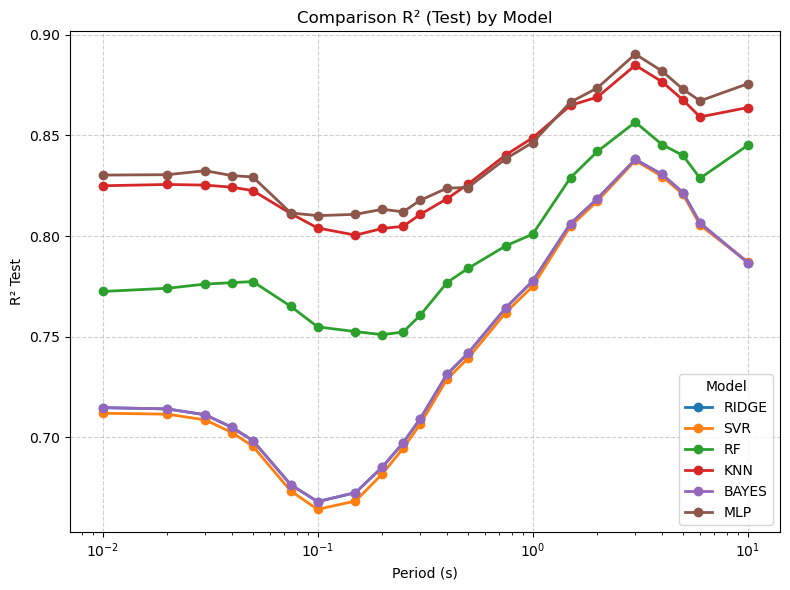

In [117]:

# Dicc con todos tus DataFrames por modelo (ajusta según tus variables)
dfs_modelos = {
    "ridge": df_ridge,
    "svr": df_svr,
    "rf": df_rf,
    #"xgb": df_xgb,
    "knn": df_knn,
    "bayes": df_bayes,
    "mlp": df_mlp
}

plt.figure(figsize=(8,6))

for nombre, df in dfs_modelos.items():
    if "R2_test" not in df.columns:
        print(f"⚠️  {nombre} no tiene columna 'R2_test'")
        continue
    
    df_plot = df.sort_values("Periodo (s)")
    plt.plot(
        df_plot["Periodo (s)"],
        df_plot["R2_test"],
        marker='o',
        linewidth=2,
        label=nombre.upper()
    )
plt.xscale("log")
plt.xlabel("Period (s)")
plt.ylabel("R² Test")
plt.title("Comparison R² (Test) by Model")
plt.legend(title="Model", loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


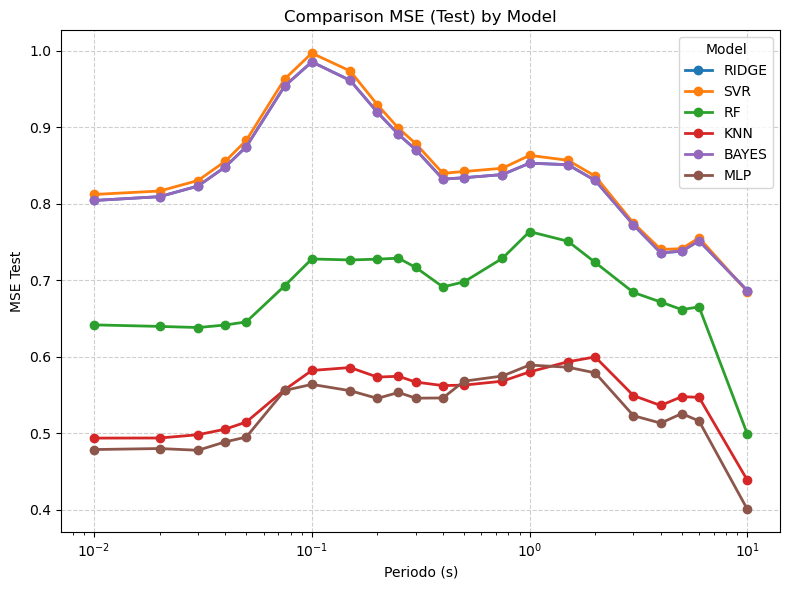

In [118]:
# Dicc con todos tus DataFrames por modelo (ajusta según tus variables)
dfs_modelos = {
    "ridge": df_ridge,
    "svr": df_svr,
    "rf": df_rf,
    #"xgb": df_xgb,
    "knn": df_knn,
    "bayes": df_bayes,
    "mlp": df_mlp
}

plt.figure(figsize=(8,6))

for nombre, df in dfs_modelos.items():
    if "MSE_test" not in df.columns:
        print(f"⚠️  {nombre} no tiene columna 'R2_test'")
        continue
    
    df_plot = df.sort_values("Periodo (s)")
    plt.plot(
        df_plot["Periodo (s)"],
        df_plot["MSE_test"],
        marker='o',
        linewidth=2,
        label=nombre.upper()
    )
plt.xscale("log")
plt.xlabel("Periodo (s)")
plt.ylabel("MSE Test")
plt.title("Comparison MSE (Test) by Model")
plt.legend(title="Model", loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [119]:
# Partiendo de df_largo creado arriba:
df_ancho = (
    df_largo
    .melt(id_vars=["modelo", "Periodo (s)"], value_vars=metric_cols,
          var_name="metrica", value_name="valor")
    .pivot_table(index="modelo", columns=["metrica", "Periodo (s)"], values="valor")
    .sort_index(axis=1, level=[0,1])
)

df_ancho

metrica      MAE_test                                                    \
Periodo (s)    0.010     0.020     0.030     0.040     0.050     0.075    
modelo                                                                    
bayes        0.697374  0.699513  0.705796  0.716701  0.727451  0.763676   
knn          0.535666  0.535656  0.538182  0.542596  0.547492  0.568821   
mlp          0.542767  0.543315  0.541138  0.547446  0.551667  0.584446   
rf           0.626134  0.624809  0.624510  0.625907  0.627636  0.648323   
ridge        0.697379  0.699519  0.705803  0.716704  0.727453  0.763684   
svr          0.693579  0.695777  0.702298  0.713752  0.725413  0.760862   

metrica                                              ... RMSE_train            \
Periodo (s)    0.100     0.150     0.200     0.250   ...     0.500     0.750    
modelo                                               ...                        
bayes        0.776297  0.770444  0.750695  0.738454  ...   0.885995  0.880154   
knn          0.580800  0.583803  0.578882  0.581256  ...   0.595808  0.597739   
mlp          0.588524  0.580519  0.578070  0.587190  ...   0.723148  0.717351   
rf           0.666535  0.666753  0.669095  0.669582  ...   0.811457  0.826054   
ridge        0.776304  0.770469  0.750707  0.738460  ...   0.885995  0.880154   
svr          0.774607  0.766286  0.747015  0.735065  ...   0.888260  0.881690   

metrica                                                                  \
Periodo (s)    1.000     1.500     2.000     3.000     4.000     5.000    
modelo                                                                    
bayes        0.894956  0.901353  0.889256  0.883776  0.851813  0.858653   
knn          0.607372  0.607326  0.598688  0.596561  0.584814  0.581975   
mlp          0.736738  0.737396  0.730877  0.711995  0.693679  0.700949   
rf           0.853346  0.844424  0.827184  0.816569  0.795288  0.787991   
ridge        0.894956  0.901353  0.889256  0.883776  0.851813  0.858653   
svr          0.896724  0.902475  0.890417  0.884597  0.852779  0.859691   

metrica                          
Periodo (s)    6.000     10.000  
modelo                           
bayes        0.871293  0.845580  
knn          0.591035  0.526674  
mlp          0.669631  0.601988  
rf           0.791535  0.694003  
ridge        0.871294  0.845580  
svr          0.872315  0.846648  

[6 rows x 176 columns]

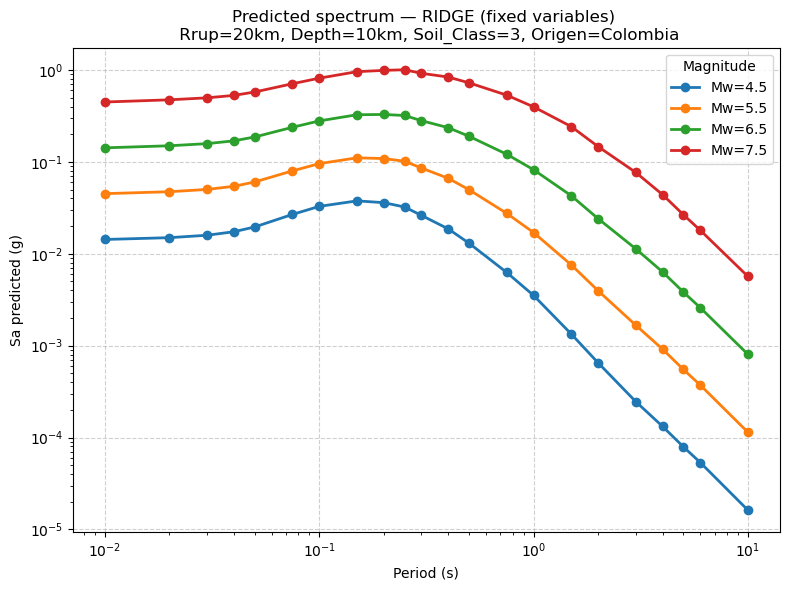

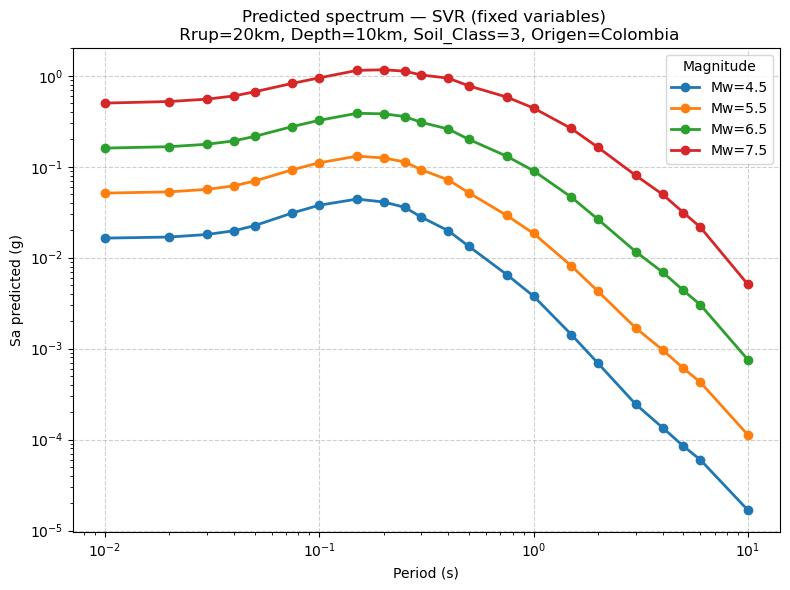

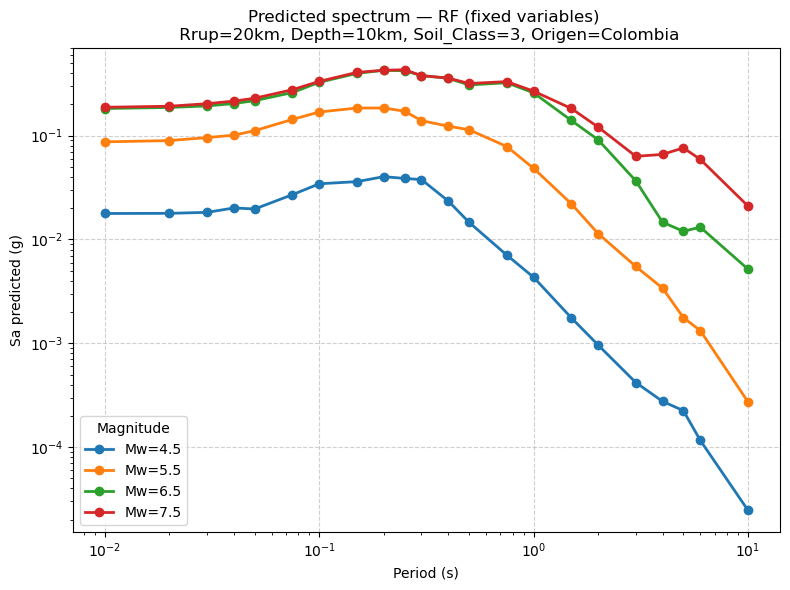

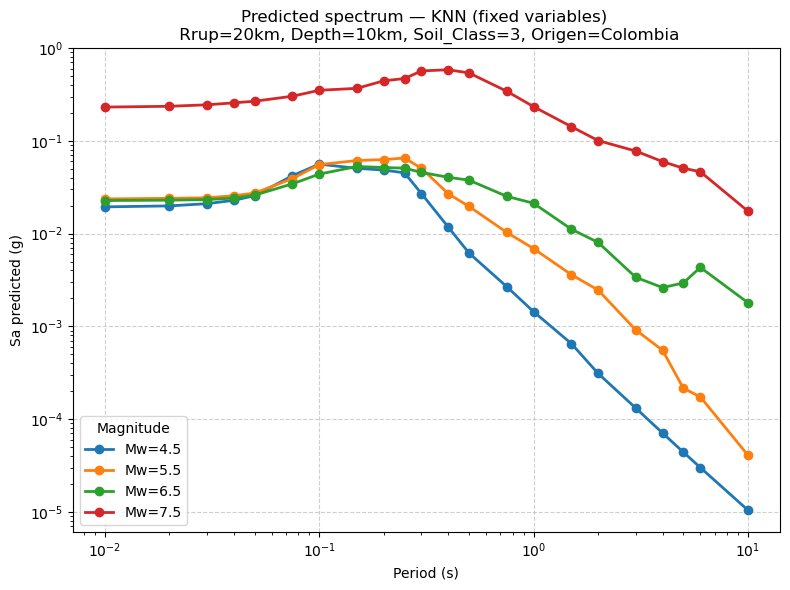

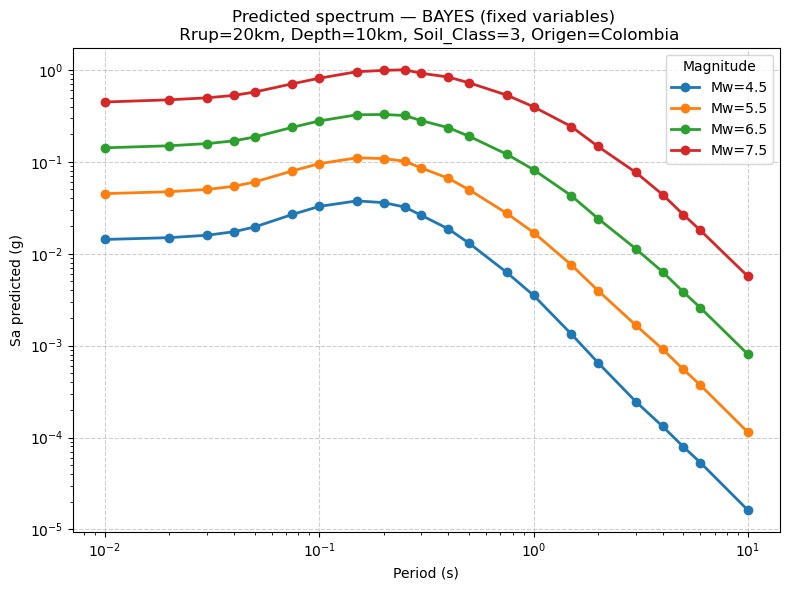

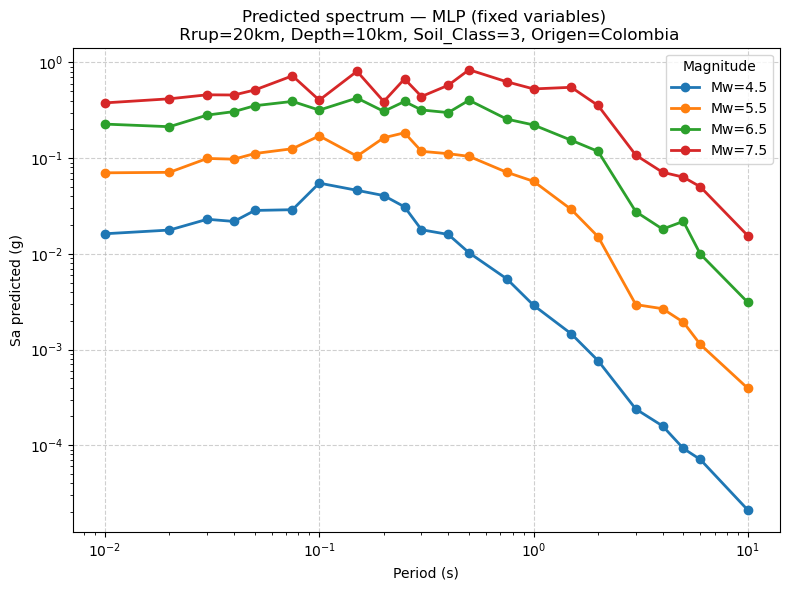

In [120]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ======== 1) PREPROCESADOR (usa exactamente X_train del entrenamiento) ========
# Si ya tenías un 'pre' fit del entrenamiento, úsalo directamente:
# pre = TU_PREPROCESADOR_FIT
# Si no, lo creamos y lo fiteamos con X_train "crudo" (con categóricas):
cat_cols = ["Soil_Class", "origen"]                     # <-- nombres EXACTOS usados en train
num_cols = [c for c in X_train.columns if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
).fit(X_train)  # <<-- idealmente ya estaba fit del entrenamiento; si no, lo fiteamos ahora

# ======== 2) CONFIGURACIÓN DE LOS ESCENARIOS ========
MAG_LIST = [4.5, 5.5, 6.5, 7.5]
MAG_COL = "Magnitude"    # nombre EXACTO de la columna de magnitud en tu X (respetar mayúsculas)

# Usa los mismos nombres y tipos que en X_train (nota: 'Origen' con O mayúscula)
FIXED = {
    "Rrup_OpenQuake": np.log(20),
    "Hypocenter Depth (km)": 10,
    "Soil_Class": "3",        # si en train era string/categoría; si era numérico, pon 2 (int)
    "origen": "Colombia",     # ojo a la mayúscula
}

# ======== 3) HELPERS ========
def extraer_periodo_from_key(k: str, regex=r"T_([0-9]*\.?[0-9]+)"):
    m = re.search(regex, str(k))
    return float(m.group(1)) if m else np.nan

def ordenar_claves_por_periodo(modelos_por_periodo: dict):
    pares = []
    for k in modelos_por_periodo.keys():
        T = extraer_periodo_from_key(k)
        pares.append((T, k))
    pares = [(T, k) for (T, k) in pares if not np.isnan(T)]
    pares.sort(key=lambda x: x[0])
    periodos = np.array([p for p, _ in pares], dtype=float)
    claves   = [k for _, k in pares]
    return periodos, claves

def preparar_input_df(magnitud: float):
    # Crea DataFrame de 1 fila con las columnas que espera el preprocesador
    row = {**FIXED, MAG_COL: magnitud}
    df = pd.DataFrame([row])
    # Opcional: alinear columnas con X_train por si faltara alguna (fill con NaN/0):
    # df = df.reindex(columns=X_train.columns, fill_value=np.nan)
    return df

def predecir_espectro(modelos_por_periodo: dict, X_evento_2d):
    # X_evento_2d ya debe estar transformado (numérico)
    periodos, claves = ordenar_claves_por_periodo(modelos_por_periodo)
    Sa = []
    for key in claves:
        mdl = modelos_por_periodo[key]
        yhat = mdl.predict(X_evento_2d)[0]
        Sa.append(yhat)
    return periodos, np.array(Sa)

# ======== 4) UN PLOT POR MODELO, 4 CURVAS (UNA POR Mw) ========
# modelos_resultados: {"ridge": {"modelos": {...}, "metricas": df}, ...}
for nombre_modelo, pack in modelos_resultados.items():
    modelos_por_periodo = pack["modelos"]

    # Descubre periodos/orden 1 sola vez
    periodos, _ = ordenar_claves_por_periodo(modelos_por_periodo)

    plt.figure(figsize=(8,6))
    for mag in MAG_LIST:
        # 1) Evento crudo (con strings categóricos válidos)
        X_evento_df = preparar_input_df(mag)

        # 2) Transformación a numérico con el mismo preprocesador del train
        X_evento_num = pre.transform(X_evento_df)  # <<-- clave para evitar "could not convert string to float"

        # 3) Predice espectro completo
        p, sa = predecir_espectro(modelos_por_periodo, X_evento_num)

        # 4) Traza
        plt.plot(p, np.exp(sa), marker='o', linewidth=2, label=f"Mw={mag}")

    plt.xlabel("Period (s)")
    plt.ylabel("Sa predicted (g)")
    plt.title(f"Predicted spectrum — {nombre_modelo.upper()} (fixed variables) \n Rrup=20km, Depth=10km, Soil_Class=3, Origen=Colombia")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Magnitude", loc="best")
    # Para espectros suele ser útil:
    plt.yscale('log')
    plt.xscale('log')
    plt.tight_layout()
    plt.show()


## Si se quiere entrenar un diferente modelo por columna: (No terminado)

In [121]:
# Supón que las columnas de y son strings de periodos: ["0.10","0.20","0.50","1.00",...]
cols = list(y_train.columns)

model_choice = {
    c: ("svr" if float(c) <= 0.5 else "xgb")
    for c in cols
}

# (Opcional) hiperparámetros por tipo/columna:
model_params = {
    # Ejemplo: sólo fijamos algo global de XGB; SVR usará sus defaults.
    # Si quieres por columna exacta: {"0.10": {"C":5, ...}, "1.00": {...}}
}

modelos, metricas = entrenar_modelos_por_columna(
    X_train, y_train, X_test, y_test,
    model_choice=model_choice,
    model_params=model_params,
    verbose=True
)


ValueError: could not convert string to float: 'T_0.01_RotD50'

In [ ]:
# Baseline SVR con hiperparámetros fijos (todos los periodos igual)
entrenar_modelos_por_columna(
    X_train, y_train, X_test, y_test,
    model_choice="svr",
    model_params={"kernel":"rbf","C":10,"epsilon":0.1},
)

# Distinto modelo por periodo
entrenar_modelos_por_columna(
    X_train, y_train, X_test, y_test,
    model_choice={"0.10":"svr", "0.20":"xgb", "0.30":"rf"},
)

# Con búsqueda por grid (por columna)
entrenar_modelos_por_columna(
    X_train, y_train, X_test, y_test,
    model_choice="rf",
    model_params={"min_samples_leaf":2},
    grid={"param_grid":{"n_estimators":[200,400]}, "cv":3, "n_jobs":-1, "refit":True},
    verbose=True
)
